In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import scipy
import sys

In [3]:
#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
#Path for the Data
if not os.path.exists("../data/students_dataset.csv"):
    print("Data Path does not exist. Expected in `../data/students_dataset.csv`")
    exit

data = pd.read_csv(os.path.join("../data/students_dataset.csv"))

In [5]:
#Get information about the Dataset overview
from src.functions import DataExplorer
explorer = DataExplorer(data)

#Shape/Format of the data, Descriptive Statistics
explorer.basic_stats()

#All variables are float64, some of them are qualitative (categorical) though
#2 missing values in the ca-number of vessels and thal-thalassemia features
#Negative result - no duplicated rows

Dataset Shape: (242, 14)

 Dataset Information:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

 Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        1
num         0
dtype: int64

 Check for duplicates:
0

 Descriptive Statistics


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,241.000000,241.000000,242.000000
mean,54.549587,0.681818,3.152893,130.958678,249.838843,0.144628,0.979339,149.962810,0.326446,0.999174,1.586777,0.609959,4.713693,0.458678
std,8.996981,0.466736,0.975516,17.622551,52.846867,0.352454,0.999786,22.686449,0.469885,1.122940,0.613397,0.883497,1.948552,0.499322
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,2.250000,120.000000,212.000000,0.000000,0.000000,134.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,244.500000,0.000000,0.000000,153.500000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,277.750000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


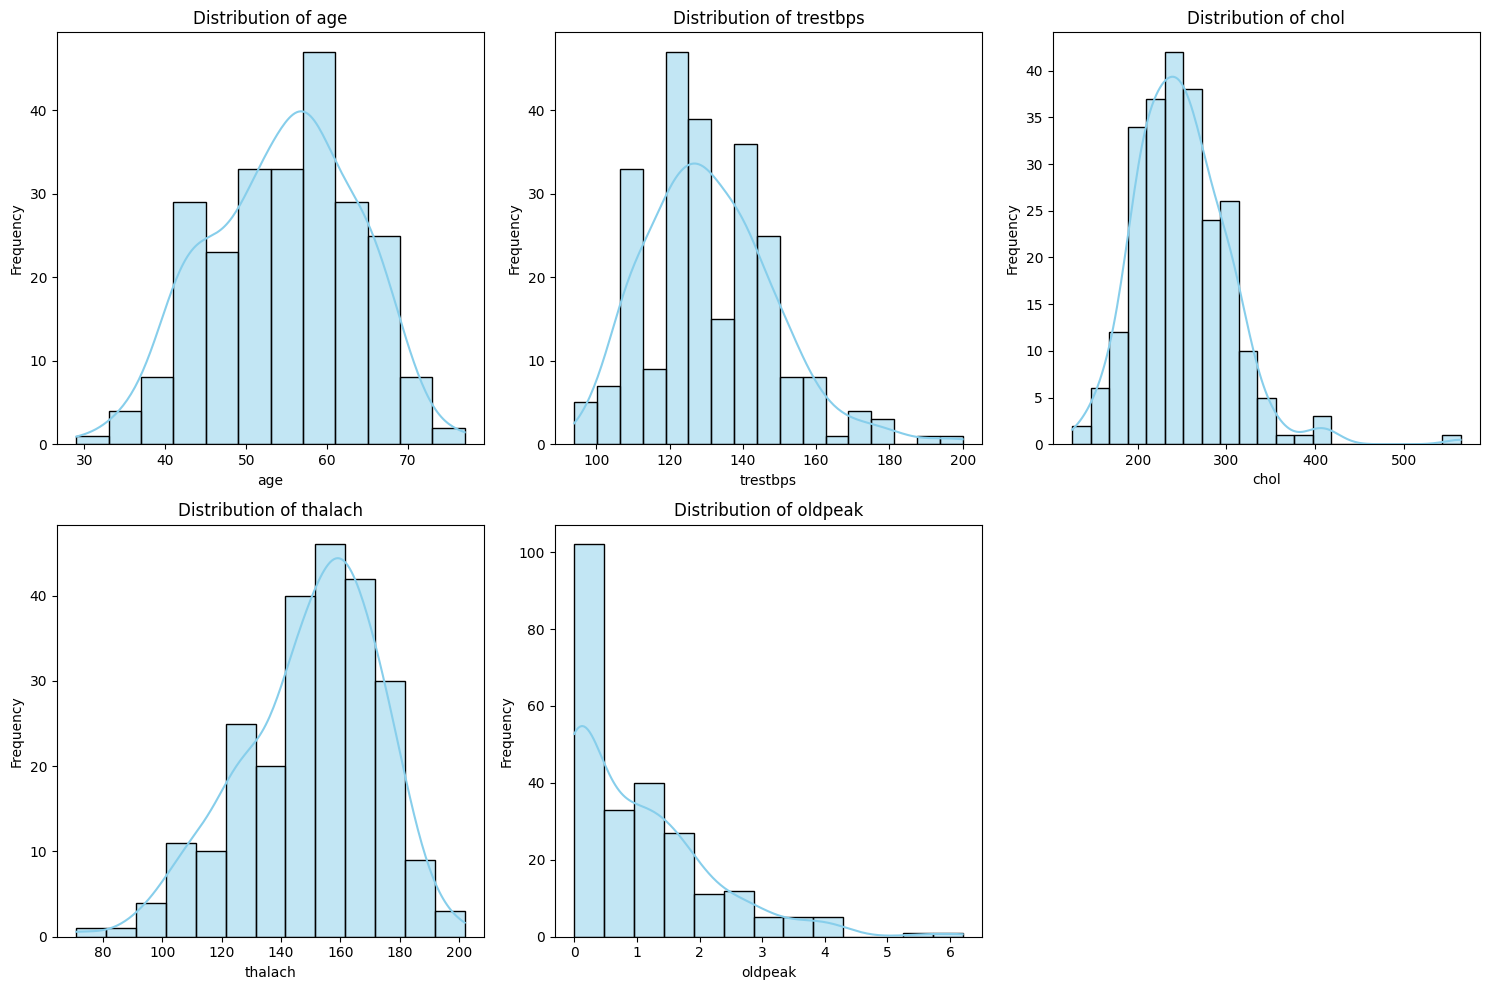

In [6]:
#Display the Distributions for the quantitative features
explorer.distributions_plots(plot_name='Distribution_quantitative.png')

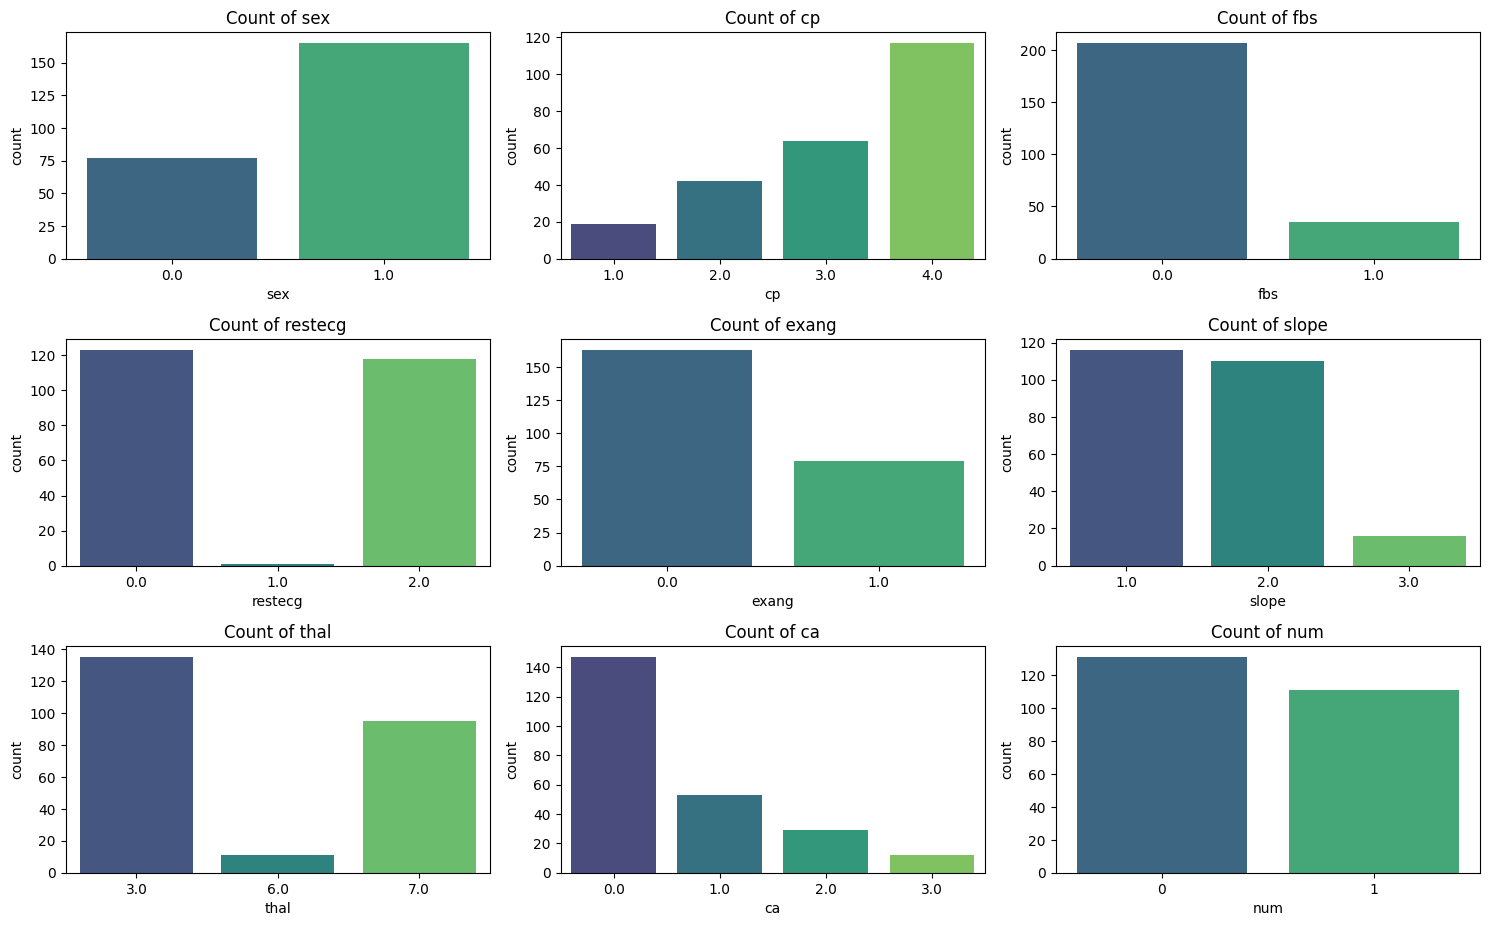

In [7]:
#Display the categorical features' frequencies 
explorer.categorical_plots(plot_name='Categorical_plots.png')

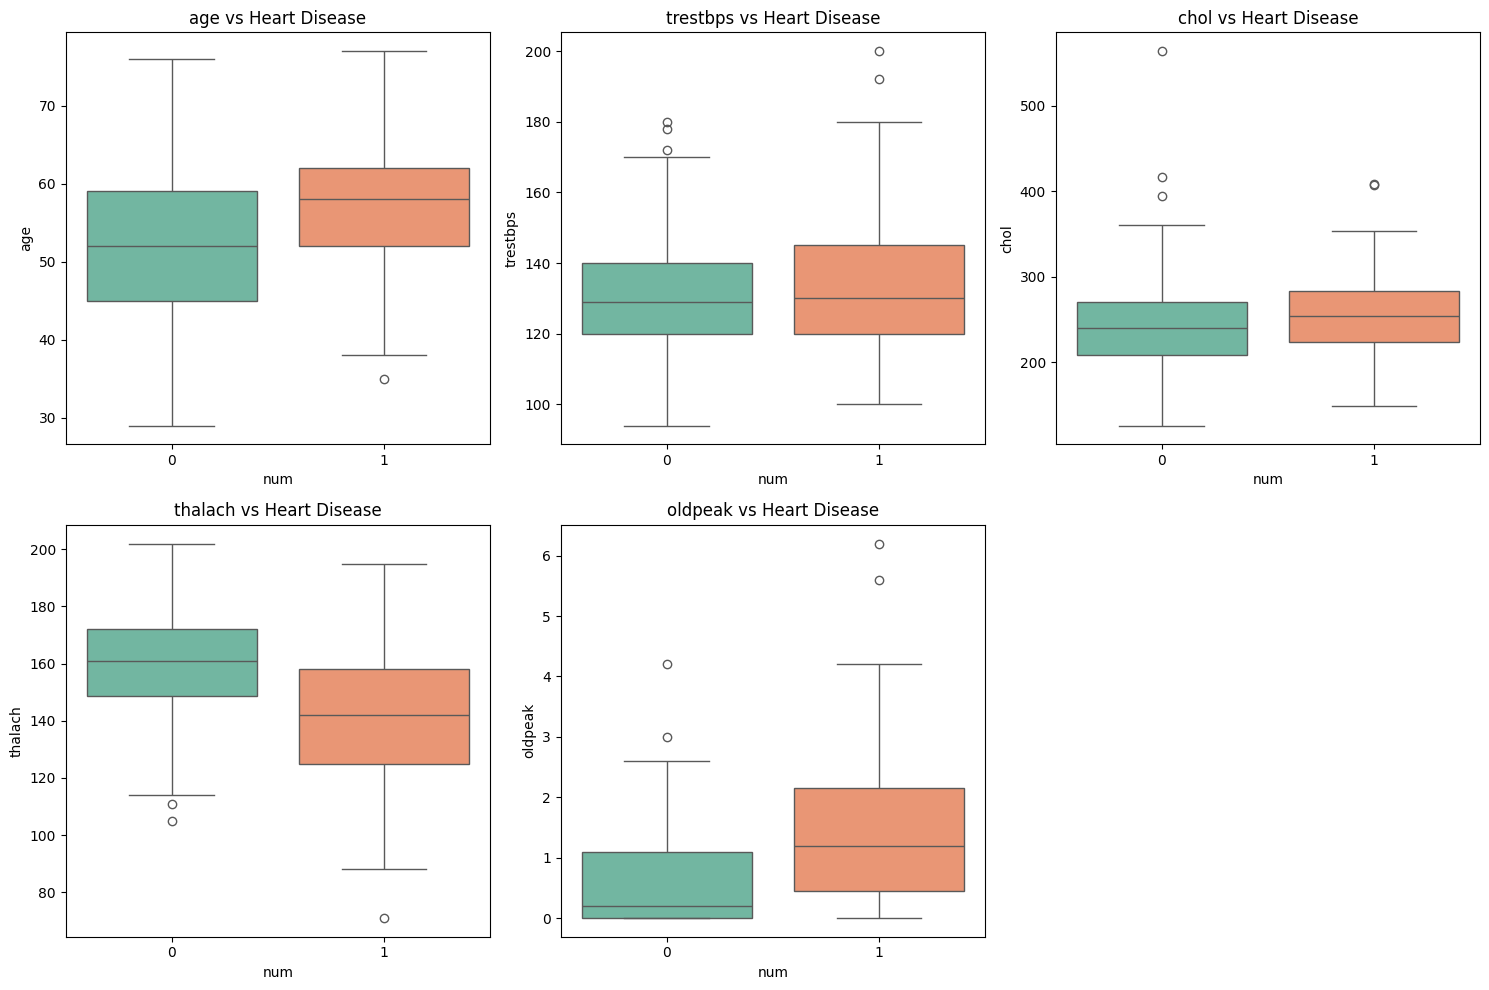

In [8]:
explorer.plot_boxplots(plot_name='Boxplots.png')

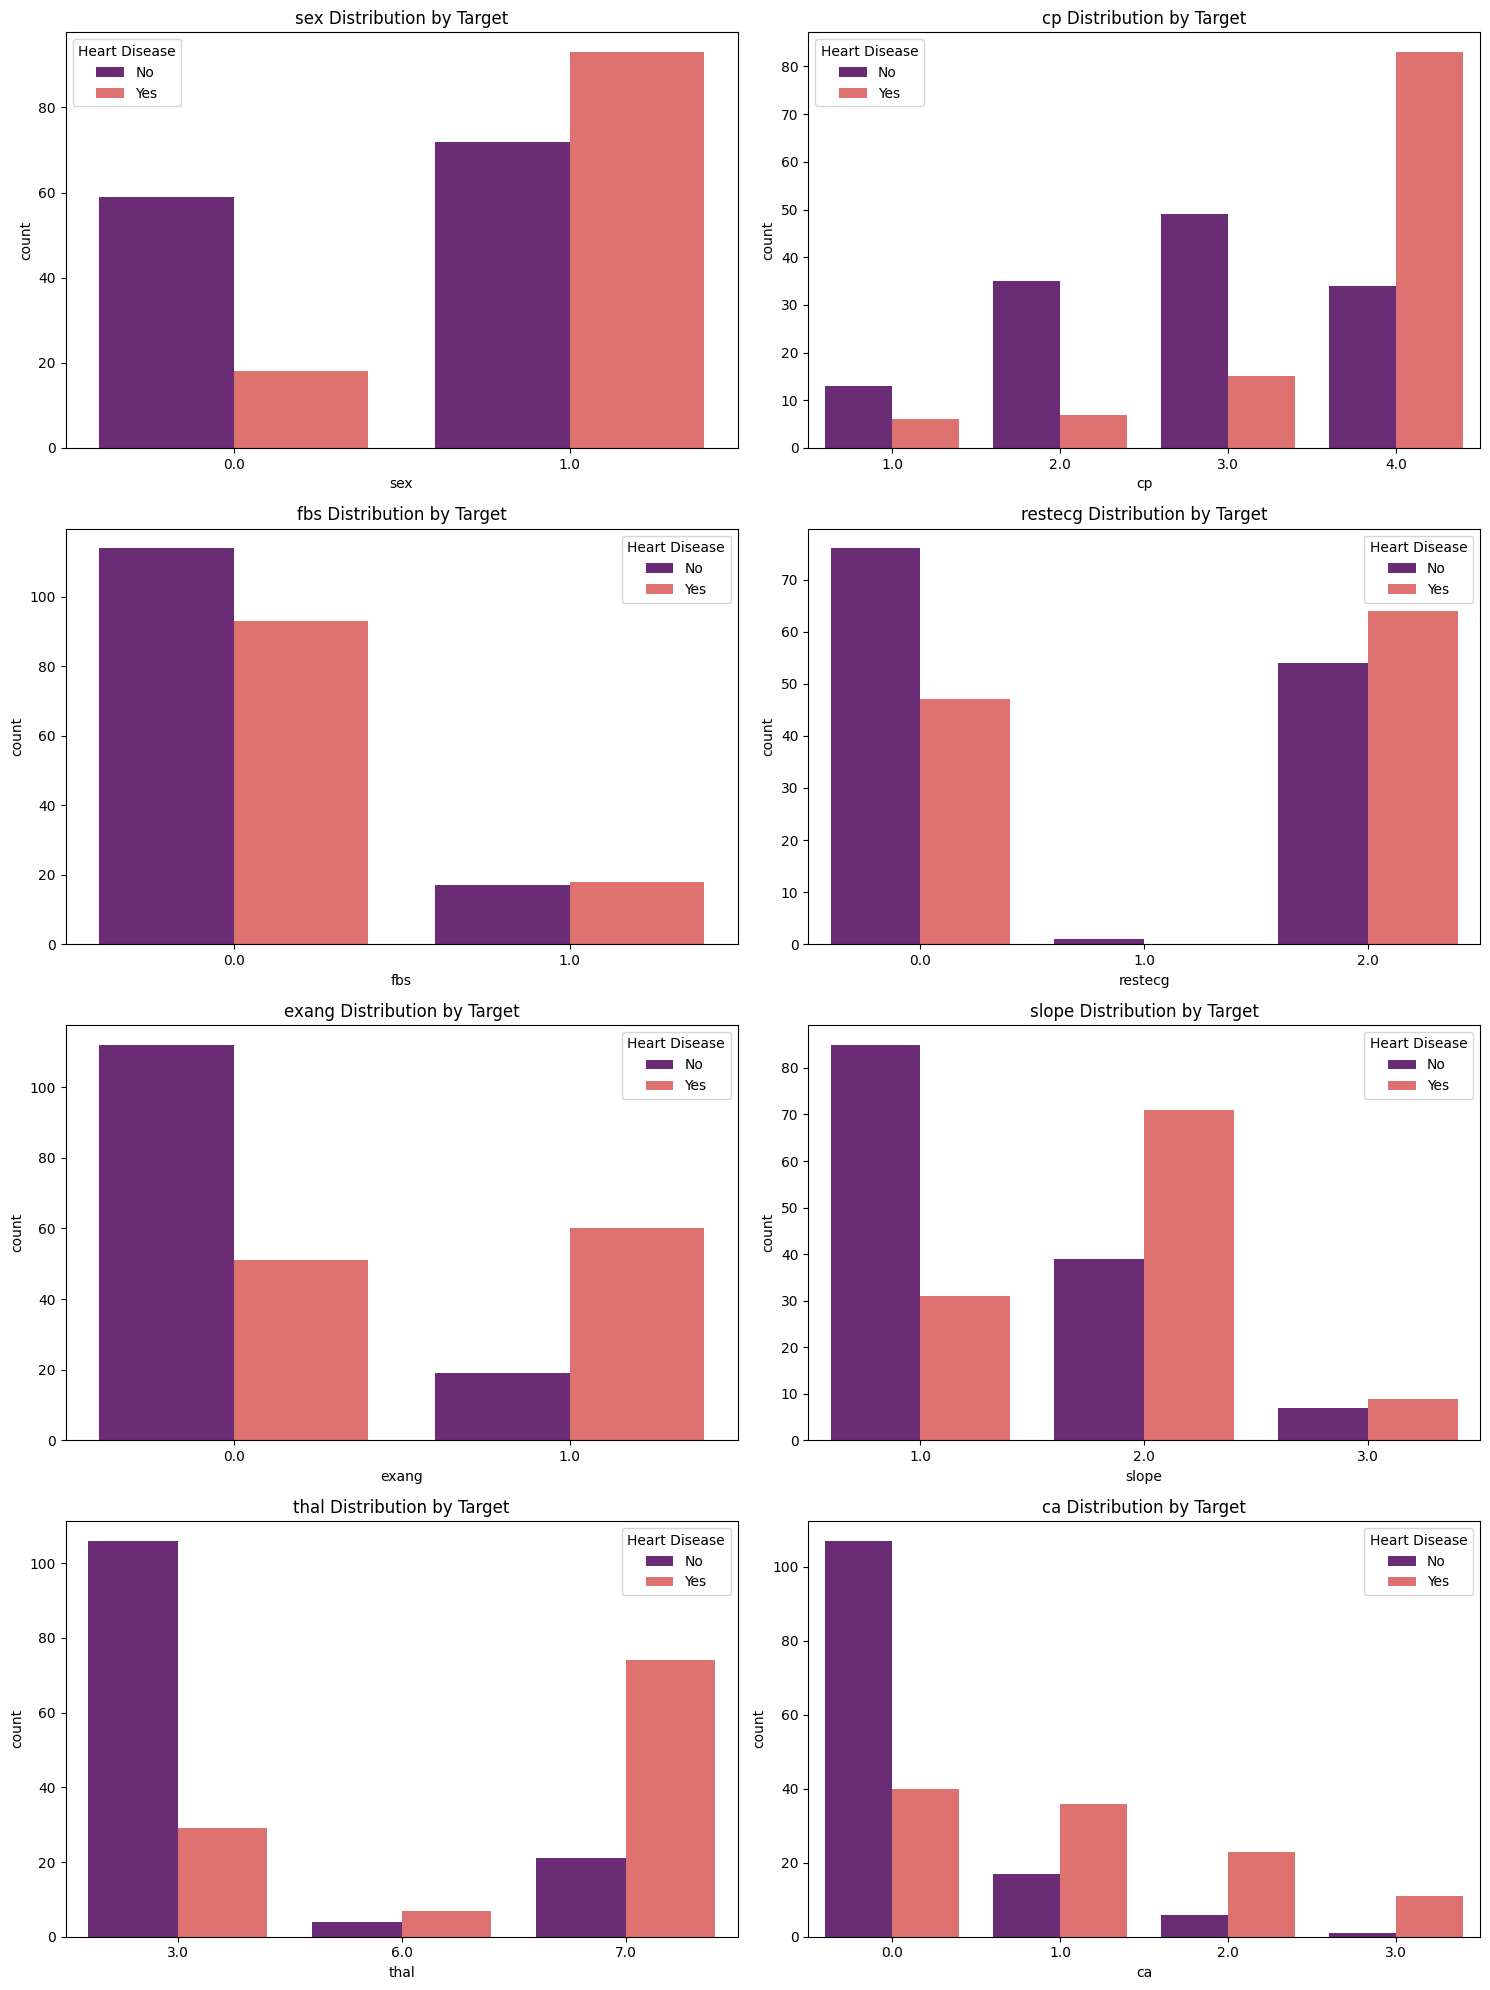

In [9]:
explorer.categorical_vs_target(plot_name='Categorical_vs_target.png')

In [16]:
from src.functions import FeatureAnalysis
feature_analyzer = FeatureAnalysis(data)

In [17]:
#Get the statistics
stats_table = feature_analyzer.run_statistical_tests()
display(stats_table)

age          | Mann-Whitney U  | 0.0007     | *
trestbps     | Mann-Whitney U  | 0.0518     | 
chol         | Mann-Whitney U  | 0.0698     | 
thalach      | Mann-Whitney U  | 0.0000     | *
oldpeak      | Mann-Whitney U  | 0.0000     | *
sex          | Chi-Square      | 0.0000     | *
cp           | Chi-Square      | 0.0000     | *
fbs          | Chi-Square      | 0.5958     | 
restecg      | Chi-Square      | 0.0290     | *
exang        | Chi-Square      | 0.0000     | *
slope        | Chi-Square      | 0.0000     | *
thal         | Chi-Square      | 0.0000     | *
ca           | Chi-Square      | 0.0000     | *


None

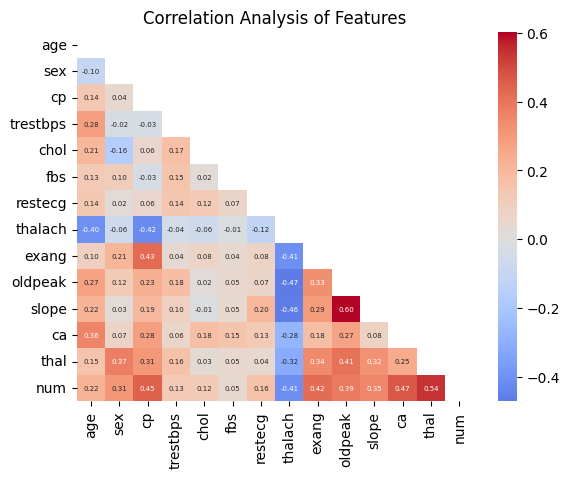

In [18]:
#Calculate and plot the heatmap correlation matrices
feature_analyzer.correlation_analysis(plot_name='Correlation_Heatmap.png')

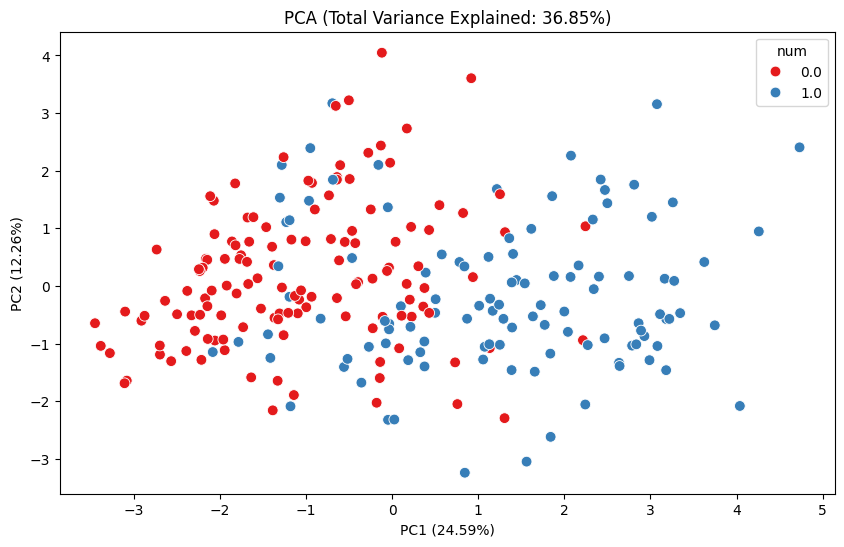

In [19]:
#Perform PCA
feature_analyzer.apply_pca(plot_name='PCA.png')